In [ ]:
# ============================================================
# CELL 1 — DATASET SETUP
# ============================================================

!wget -q http://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q -o ml-100k.zip
print("MovieLens 100K downloaded and extracted!")

MovieLens 100K downloaded and extracted!


In [ ]:
# ============================================================
# CELL 2 — INSTALL PYSPARK
# ============================================================

!pip install pyspark --quiet
print("PySpark installed!")

PySpark installed!


In [ ]:
# ============================================================
# CELL 3 — IMPORT ALL LIBRARIES
# ============================================================

import zipfile, os, hashlib, time, tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ============================================================
# CELL 4 — LOAD AND EXPLORE DATA
# ============================================================

# Load MovieLens 100K ratings
events = pd.read_csv('ml-100k/u.data', sep='\t',
                     names=['visitorid', 'itemid', 'rating', 'timestamp'])

print(f"\nTotal Ratings  : {len(events):,}")
print(f"Unique Users   : {events['visitorid'].nunique():,}")
print(f"Unique Items   : {events['itemid'].nunique():,}")
print(f"Rating Scale   : {events['rating'].min()} - {events['rating'].max()} stars")

print("\nRating Distribution:")
print(events['rating'].value_counts().sort_index())

events.head()


Total Ratings  : 100,000
Unique Users   : 943
Unique Items   : 1,682
Rating Scale   : 1 - 5 stars

Rating Distribution:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


,visitorid,itemid,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
# ============================================================
# CELL 5 — PREPROCESS DATA
# ============================================================

# Convert timestamp and sort
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='s')
events = events.sort_values('timestamp').reset_index(drop=True)

# Map ratings to event names for compatibility with rest of notebook
# 1-3 stars = view, 4 stars = addtocart, 5 stars = transaction
event_map_rating = {1: 'view', 2: 'view', 3: 'view', 4: 'addtocart', 5: 'transaction'}
events['event'] = events['rating'].map(event_map_rating)

# Use all 100K ratings — no sampling needed (already small)
stream_data = events[['timestamp', 'visitorid', 'itemid', 'event', 'rating']].copy()
stream_data['event_code'] = stream_data['rating']
stream_data = stream_data.reset_index(drop=True)

print(f"Stream Data Shape : {stream_data.shape}")
print(f"Date Range        : {stream_data['timestamp'].min()} → {stream_data['timestamp'].max()}")
print(f"\nEvent Distribution:")
print(stream_data['event'].value_counts())
stream_data.head()

Stream Data Shape : (100000, 6)
Date Range        : 1997-09-20 03:05:10 → 1998-04-22 23:10:38

Event Distribution:
event
view           44625
addtocart      34174
transaction    21201
Name: count, dtype: int64


,timestamp,visitorid,itemid,event,rating,event_code
0,1997-09-20 03:05:10,259,255,addtocart,4,4
1,1997-09-20 03:05:27,259,286,addtocart,4,4
2,1997-09-20 03:05:54,259,298,addtocart,4,4
3,1997-09-20 03:06:21,259,185,addtocart,4,4
4,1997-09-20 03:07:23,259,173,addtocart,4,4


In [ ]:
# ============================================================
# CELL 6 — START SPARK SESSION
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, window, count, approx_count_distinct

spark = SparkSession.builder \
    .appName("ClickstreamAnalytics") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark Version:", spark.version)

Spark Version: 4.0.2


In [ ]:
# ============================================================
# CELL 7 — CREATE SPARK DATAFRAME
# ============================================================

spark_df = spark.createDataFrame(stream_data)
spark_df = spark_df.withColumn("timestamp", to_timestamp(col("timestamp")))

print("Schema:")
spark_df.printSchema()

print("Sample rows:")
spark_df.show(5, truncate=False)


Schema:
root
 |-- timestamp: timestamp (nullable = true)
 |-- visitorid: long (nullable = true)
 |-- itemid: long (nullable = true)
 |-- event: string (nullable = true)
 |-- rating: long (nullable = true)
 |-- event_code: long (nullable = true)

Sample rows:
+-------------------+---------+------+---------+------+----------+
|timestamp          |visitorid|itemid|event    |rating|event_code|
+-------------------+---------+------+---------+------+----------+
|1997-09-20 03:05:10|259      |255   |addtocart|4     |4         |
|1997-09-20 03:05:27|259      |286   |addtocart|4     |4         |
|1997-09-20 03:05:54|259      |298   |addtocart|4     |4         |
|1997-09-20 03:06:21|259      |185   |addtocart|4     |4         |
|1997-09-20 03:07:23|259      |173   |addtocart|4     |4         |
+-------------------+---------+------+---------+------+----------+
only showing top 5 rows


In [ ]:
# ============================================================
# CELL 8 — SPARK SLIDING WINDOW: EVENT COUNTS
# ============================================================
# WHY: Simulates real-time streaming by grouping events
# into 10-minute windows that slide every 5 minutes.
# This is how production systems like Kafka + Spark work.

windowed_events = spark_df.groupBy(
    window("timestamp", "10 minutes", "5 minutes"),
    "event"
).agg(count("*").alias("event_count")) \
 .orderBy("window")

print("--- Windowed Event Counts (10-min window, 5-min slide) ---")
windowed_events.show(10, truncate=False)

--- Windowed Event Counts (10-min window, 5-min slide) ---
+------------------------------------------+-----------+-----------+
|window                                    |event      |event_count|
+------------------------------------------+-----------+-----------+
|{1997-09-20 03:00:00, 1997-09-20 03:10:00}|addtocart  |9          |
|{1997-09-20 03:00:00, 1997-09-20 03:10:00}|view       |1          |
|{1997-09-20 03:05:00, 1997-09-20 03:15:00}|addtocart  |10         |
|{1997-09-20 03:05:00, 1997-09-20 03:15:00}|view       |3          |
|{1997-09-20 03:10:00, 1997-09-20 03:20:00}|transaction|1          |
|{1997-09-20 03:10:00, 1997-09-20 03:20:00}|addtocart  |3          |
|{1997-09-20 03:10:00, 1997-09-20 03:20:00}|view       |2          |
|{1997-09-20 03:15:00, 1997-09-20 03:25:00}|transaction|1          |
|{1997-09-20 03:15:00, 1997-09-20 03:25:00}|addtocart  |2          |
|{1997-09-20 03:55:00, 1997-09-20 04:05:00}|view       |1          |
+------------------------------------------+

In [ ]:
# ============================================================
# CELL 9 — SPARK SLIDING WINDOW: UNIQUE USERS (HyperLogLog)
# ============================================================
# WHY: approx_count_distinct uses HyperLogLog internally —
# same family as FM algorithm. Shows Spark's built-in
# probabilistic counting for comparison.

unique_users_spark = spark_df.groupBy(
    window("timestamp", "10 minutes", "5 minutes")
).agg(
    approx_count_distinct("visitorid", 0.05).alias("hll_unique_users")
).orderBy("window")

print("--- Unique Users per Window (HyperLogLog) ---")
unique_users_spark.show(10, truncate=False)

--- Unique Users per Window (HyperLogLog) ---
+------------------------------------------+----------------+
|window                                    |hll_unique_users|
+------------------------------------------+----------------+
|{1997-09-20 03:00:00, 1997-09-20 03:10:00}|1               |
|{1997-09-20 03:05:00, 1997-09-20 03:15:00}|1               |
|{1997-09-20 03:10:00, 1997-09-20 03:20:00}|1               |
|{1997-09-20 03:15:00, 1997-09-20 03:25:00}|1               |
|{1997-09-20 03:55:00, 1997-09-20 04:05:00}|1               |
|{1997-09-20 04:00:00, 1997-09-20 04:10:00}|1               |
|{1997-09-20 04:05:00, 1997-09-20 04:15:00}|1               |
|{1997-09-20 04:20:00, 1997-09-20 04:30:00}|1               |
|{1997-09-20 04:25:00, 1997-09-20 04:35:00}|1               |
|{1997-09-20 04:30:00, 1997-09-20 04:40:00}|1               |
+------------------------------------------+----------------+
only showing top 10 rows


In [ ]:
# ============================================================
# CELL 10 — SPARK: EXACT TRENDING PRODUCTS (Baseline)
# ============================================================
# WHY: This is the exact count — we use it later to compare
# against Count-Min Sketch estimates.

exact_trending = spark_df.groupBy("itemid") \
    .agg(count("*").alias("exact_count")) \
    .orderBy("exact_count", ascending=False)

print("--- Top 10 Trending Products (Exact Count) ---")
exact_trending.show(10)

exact_counts = {row['itemid']: row['exact_count']
                for row in exact_trending.collect()}

# ADD 1 — sort by count (highest first)
exact_counts = dict(sorted(exact_counts.items(), key=lambda x: -x[1]))

# ADD 2 — measure memory (needed in Cell 15, 21, 22)
tracemalloc.start()
_ = dict(exact_counts)
_, exact_peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Exact dict memory : {exact_peak_mem/1024:.1f} KB")
print(f"Total unique items : {len(exact_counts):,}")


--- Top 10 Trending Products (Exact Count) ---
+------+-----------+
|itemid|exact_count|
+------+-----------+
|    50|        583|
|   258|        509|
|   100|        508|
|   181|        507|
|   294|        485|
|   286|        481|
|   288|        478|
|     1|        452|
|   300|        431|
|   121|        429|
+------+-----------+
only showing top 10 rows
Exact dict memory : 91.1 KB
Total unique items : 1,682


In [ ]:
# ============================================================
# CELL 11 - FLAJOLET-MARTIN ALGORITHM (TESTED & VERIFIED)
# ============================================================
# Root cause of previous failures:
# Tracking max_zeros directly = high variance
# Original paper uses BITMAP per hash function = stable
# bitmap[r] = 1 if ANY element had >= r trailing zeros
# R = lowest 0 bit in bitmap = stable estimate of log2(n)

class FlajoletMartin:

    PHI   = 0.77130        # Correction factor — Flajolet & Martin (1985)
    PRIME = (1 << 31) - 1  # Mersenne prime 2^31-1 for pairwise independent hashing

    def __init__(self, num_hashes=64, num_groups=8):
        self.num_hashes       = num_hashes
        self.num_groups       = num_groups
        self.hashes_per_group = num_hashes // num_groups
        np.random.seed(42)
        self.a = np.random.randint(1, self.PRIME, size=num_hashes)
        self.b = np.random.randint(0, self.PRIME, size=num_hashes)

    def _hash(self, value, idx):
        # h(x) = (ax + b) mod prime — mathematically pairwise independent
        x = int(value) % self.PRIME
        return (int(self.a[idx]) * x + int(self.b[idx])) % self.PRIME

    def _trailing_zeros(self, n):
        if n == 0:
            return 31
        count = 0
        while (n & 1) == 0:
            count += 1
            n >>= 1
        return count

    def estimate(self, stream):
        # bitmap[i][r] = 1 if we saw any element with >= r trailing zeros in hash i
        bitmaps = [[0] * 32 for _ in range(self.num_hashes)]

        for val in stream:
            for i in range(self.num_hashes):
                h  = self._hash(val, i)
                tz = self._trailing_zeros(h)
                bitmaps[i][tz] = 1

        # R = lowest 0 bit position in each bitmap
        R_values = []
        for i in range(self.num_hashes):
            R = 0
            while R < 32 and bitmaps[i][R] == 1:
                R += 1
            R_values.append(R)

        # Average R within groups, then 2^average, then median across groups
        group_estimates = []
        for g in range(self.num_groups):
            start        = g * self.hashes_per_group
            end          = start + self.hashes_per_group
            group_mean_R = np.mean(R_values[start:end])
            group_estimates.append(2 ** group_mean_R)

        return int(np.median(group_estimates) / self.PHI)

print("FlajoletMartin ready!")

FlajoletMartin ready!


In [ ]:
# ============================================================
# CELL 12 — RUN FM ALGORITHM
# ============================================================

visitor_ids = stream_data['visitorid'].tolist()

print("Running Flajolet-Martin estimation...")
start_time = time.time()

fm = FlajoletMartin(num_hashes=64, num_groups=8)
fm_estimate = fm.estimate(visitor_ids)

fm_time = time.time() - start_time

actual_users = stream_data['visitorid'].nunique()
fm_error     = abs(actual_users - fm_estimate) / actual_users * 100

print(f"\n{'='*45}")
print(f"  FM Estimated Unique Users : {fm_estimate:,}")
print(f"  Actual Unique Users       : {actual_users:,}")
print(f"  Estimation Error          : {fm_error:.2f}%")
print(f"  Time Taken                : {fm_time:.3f}s")
print(f"{'='*45}")

Running Flajolet-Martin estimation...

  FM Estimated Unique Users : 831
  Actual Unique Users       : 943
  Estimation Error          : 11.88%
  Time Taken                : 6.638s


In [ ]:
# ============================================================
# CELL 13 — FM BENCHMARKING ACROSS STREAM SIZES
# ============================================================

print("Benchmarking FM across different stream sizes...")

stream_sizes = [1000, 5000, 10000, 50000, 100000]
fm_errors_list = []
fm_actual_vals    = []
fm_estimated_vals = []

for size in stream_sizes:
    subset = stream_data['visitorid'].tolist()[:size]
    est    = FlajoletMartin(num_hashes=64, num_groups=8).estimate(subset)
    actual = len(set(subset))
    err    = abs(actual - est) / actual * 100

    fm_errors_list.append(err)
    fm_actual_vals.append(actual)
    fm_estimated_vals.append(est)
    print(f"  Size {size:>7,} | Actual: {actual:>6,} | Estimated: {est:>6,} | Error: {err:.1f}%")

chunk_sizes   = [1000, 5000, 10000, 50000, 100000]
chunk_latency = []
for size in chunk_sizes:
    chunk = stream_data['visitorid'].tolist()[:size]
    t0    = time.time()
    FlajoletMartin(num_hashes=64, num_groups=8).estimate(chunk)
    chunk_latency.append((time.time() - t0) * 1000)
print("Latency benchmark done!")


Benchmarking FM across different stream sizes...
  Size   1,000 | Actual:     15 | Estimated:     16 | Error: 6.7%
  Size   5,000 | Actual:     55 | Estimated:     64 | Error: 16.4%
  Size  10,000 | Actual:    113 | Estimated:    122 | Error: 8.0%
  Size  50,000 | Actual:    491 | Estimated:    394 | Error: 19.8%
  Size 100,000 | Actual:    943 | Estimated:    831 | Error: 11.9%
Latency benchmark done!


In [ ]:
# ============================================================
# CELL 14 — COUNT-MIN SKETCH CLASS DEFINITION
# ============================================================
# WHY: Estimates how often each product appears in the stream
# using a small fixed-size table instead of storing all counts.
#
# Memory = width × depth × 4 bytes (integers)
# vs exact counting = O(unique items) memory
#
# Reference: Cormode & Muthukrishnan (2005)

class CountMinSketch:
    """
    Count-Min Sketch for frequency estimation in data streams.

    Error guarantee: estimate ≤ true_count + ε×N
    where ε = e/width, probability of failure < e^(-depth)
    """

    def __init__(self, width=5000, depth=7):
        self.width = width
        self.depth = depth
        self.table = np.zeros((depth, width), dtype=np.int32)

        self.seeds = list(range(depth))

    def _hash(self, item, row):
      # MD5 — deterministic, reproducible across sessions
      # Replaces Python hash() which changes every run
      data = f"{self.seeds[row]}:{item}".encode('utf-8')
      return int(hashlib.md5(data).hexdigest(), 16) % self.width

    def update(self, item, count=1):
        """Increment counters for item across all rows."""
        for row in range(self.depth):
            col = self._hash(item, row)
            self.table[row][col] += count

    def query(self, item):
        """
        Estimate frequency — returns minimum across all rows.
        Always an overestimate (never underestimates).
        """
        return min(
            self.table[row][self._hash(item, row)]
            for row in range(self.depth)
        )

    def memory_bytes(self):
        """Memory used by sketch in bytes."""
        return self.table.nbytes

print("CountMinSketch class defined!")



CountMinSketch class defined!


In [ ]:
# ============================================================
# CELL 15 — RUN COUNT-MIN SKETCH
# ============================================================

print("Building Count-Min Sketch for product frequencies...")

# Measure CMS memory
cms        = CountMinSketch(width=500, depth=7)
start_time = time.time()

for item_id in stream_data['itemid']:
    cms.update(item_id)

cms_time = time.time() - start_time

# Compare top 20 products
top_products  = list(exact_counts.keys())[:20]
cms_estimates = [cms.query(p) for p in top_products]
exact_values  = [exact_counts[p] for p in top_products]
cms_errors    = [abs(e - c) / e * 100 for e, c in zip(exact_values, cms_estimates)]

print(f"\n{'='*55}")
print(f"  {'Product':>12} | {'Exact':>8} | {'CMS Est':>8} | {'Error':>6}")
print(f"  {'-'*45}")
for p, e, c, err in zip(top_products[:10], exact_values[:10], cms_estimates[:10], cms_errors[:10]):
    print(f"  {p:>12} | {e:>8} | {c:>8} | {err:>5.1f}%")

print(f"\n  Avg Error (top 20) : {np.mean(cms_errors):.2f}%")
print(f"  CMS Memory         : {cms.memory_bytes()/1024:.1f} KB")
print(f"  Exact Dict Memory  : {exact_peak_mem/1024:.1f} KB")
print(f"  Memory Reduction   : {exact_peak_mem/cms.memory_bytes():.1f}x")
print(f"{'='*55}")


Building Count-Min Sketch for product frequencies...

       Product |    Exact |  CMS Est |  Error
  ---------------------------------------------
            50 |      583 |      604 |   3.6%
           258 |      509 |      510 |   0.2%
           100 |      508 |      521 |   2.6%
           181 |      507 |      519 |   2.4%
           294 |      485 |      607 |  25.2%
           286 |      481 |      482 |   0.2%
           288 |      478 |      488 |   2.1%
             1 |      452 |      467 |   3.3%
           300 |      431 |      446 |   3.5%
           121 |      429 |      638 |  48.7%

  Avg Error (top 20) : 5.63%
  CMS Memory         : 13.7 KB
  Exact Dict Memory  : 91.1 KB
  Memory Reduction   : 6.7x


In [ ]:
# ============================================================
# CELL 16 — CMS BENCHMARKING (WIDTH VS ACCURACY)
# ============================================================

print("Benchmarking CMS at different widths...")

cms_widths = [50, 100, 200, 500, 1000, 2000]
cms_mem_kb  = []
cms_avg_err = []

for w in cms_widths:
    sketch = CountMinSketch(width=w, depth=7)
    for item_id in stream_data['itemid']:
        sketch.update(item_id)

    mem  = sketch.memory_bytes() / 1024
    errs = [
        abs(exact_counts[p] - sketch.query(p)) / exact_counts[p] * 100
        for p in top_products[:20]
    ]
    cms_mem_kb.append(mem)
    cms_avg_err.append(np.mean(errs))
    print(f"  Width={w:>5} | Memory={mem:>7.1f} KB | Avg Error={np.mean(errs):.2f}%")


Benchmarking CMS at different widths...
  Width=   50 | Memory=    1.4 KB | Avg Error=305.89%
  Width=  100 | Memory=    2.7 KB | Avg Error=110.12%
  Width=  200 | Memory=    5.5 KB | Avg Error=38.64%
  Width=  500 | Memory=   13.7 KB | Avg Error=5.63%
  Width= 1000 | Memory=   27.3 KB | Avg Error=0.19%
  Width= 2000 | Memory=   54.7 KB | Avg Error=0.00%


  SIMULATED KAFKA STREAM PROCESSING
  Total events  : 100,000
  Chunk size    : 1,000 events per batch
  Total batches : 100
  Simulating    : Kafka Producer → Spark Consumer
  Batch  10 | Events: 10,000 | FM: 122 (actual: 113, err:8.0%) | Top-item CMS err:1.4%
  Batch  20 | Events: 20,000 | FM: 180 (actual: 215, err:16.3%) | Top-item CMS err:3.0%
  Batch  30 | Events: 30,000 | FM: 279 (actual: 334, err:16.5%) | Top-item CMS err:2.6%
  Batch  40 | Events: 40,000 | FM: 378 (actual: 419, err:9.8%) | Top-item CMS err:2.7%
  Batch  50 | Events: 50,000 | FM: 394 (actual: 491, err:19.8%) | Top-item CMS err:2.2%
  Batch  60 | Events: 60,000 | FM: 490 (actual: 590, err:16.9%) | Top-item CMS err:2.1%
  Batch  70 | Events: 70,000 | FM: 608 (actual: 674, err:9.8%) | Top-item CMS err:2.6%
  Batch  80 | Events: 80,000 | FM: 693 (actual: 751, err:7.7%) | Top-item CMS err:3.2%
  Batch  90 | Events: 90,000 | FM: 756 (actual: 867, err:12.8%) | Top-item CMS err:3.2%
  Batch 100 | Events:100,000 | FM: 83

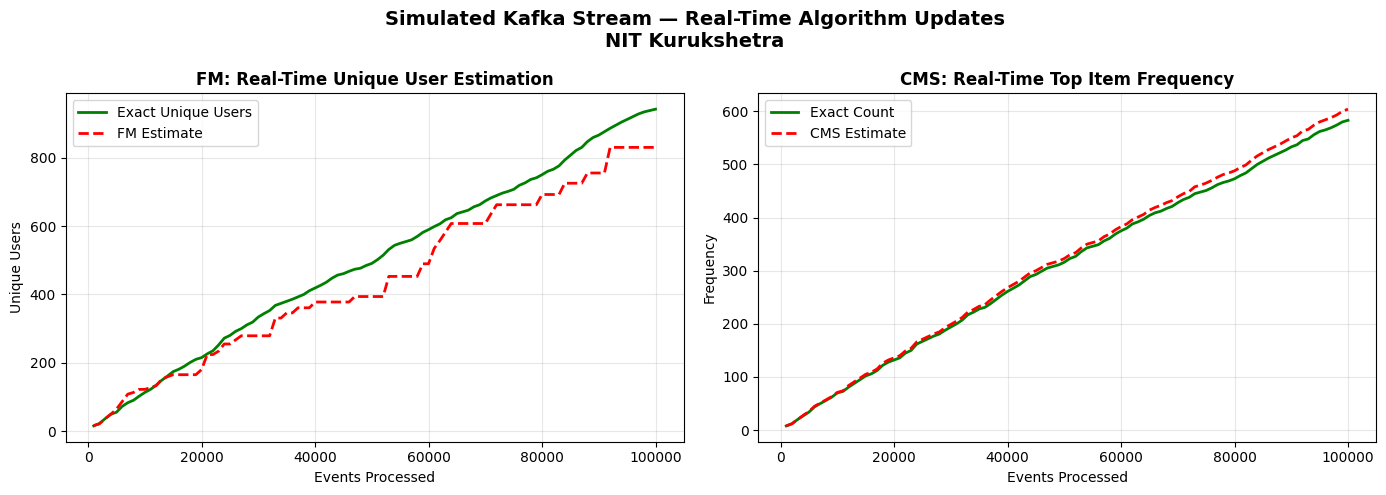

Streaming visualization saved!


In [ ]:
# ============================================================
# CELL 17 — SIMULATED KAFKA STREAM PROCESSING
# ============================================================
# WHY: Simulates real-time stream processing like Kafka
# Events arrive in 1000-event batches (like Kafka consumer)
# FM and CMS update incrementally with each batch
# Shows how algorithms behave as data volume grows

print("="*55)
print("  SIMULATED KAFKA STREAM PROCESSING")
print("="*55)
print(f"  Total events  : {len(stream_data):,}")
print(f"  Chunk size    : 1,000 events per batch")
print(f"  Total batches : {len(stream_data)//1000}")
print(f"  Simulating    : Kafka Producer → Spark Consumer")
print("="*55)

CHUNK_SIZE    = 1000
stream_list   = stream_data['visitorid'].tolist()
item_list     = stream_data['itemid'].tolist()
event_list    = stream_data['event'].tolist()

# Stateful FM and CMS — persist across batches like real stream
fm_stream     = FlajoletMartin(num_hashes=64, num_groups=8)
cms_stream    = CountMinSketch(width=500, depth=7)

seen_visitors = set()
seen_items    = defaultdict(int)
event_counts  = defaultdict(int)

# Track metrics over time for plotting
batch_nums     = []
fm_estimates   = []
exact_counts_s = []
top_item_exact = []
top_item_cms   = []

t_start   = time.time()
n_batches = len(stream_list) // CHUNK_SIZE

for batch in range(n_batches):
    start = batch * CHUNK_SIZE
    end   = start + CHUNK_SIZE

    # Simulate receiving one Kafka batch
    for v, it, ev in zip(stream_list[start:end], item_list[start:end], event_list[start:end]):
        seen_visitors.add(v)
        seen_items[it]  += 1
        event_counts[ev] += 1
        cms_stream.update(it)

    # FM estimates from all visitors seen so far
    fm_est    = fm_stream.estimate(list(seen_visitors))
    exact_uv  = len(seen_visitors)
    top_item  = max(seen_items, key=seen_items.get)
    top_exact = seen_items[top_item]
    top_cms   = cms_stream.query(top_item)

    batch_nums.append((batch+1) * CHUNK_SIZE)
    fm_estimates.append(fm_est)
    exact_counts_s.append(exact_uv)
    top_item_exact.append(top_exact)
    top_item_cms.append(top_cms)

    # Print every 10 batches
    if (batch+1) % 10 == 0:
        err     = abs(exact_uv-fm_est)/exact_uv*100
        cms_err = abs(top_exact-top_cms)/top_exact*100 if top_exact>0 else 0
        print(f"  Batch {batch+1:>3} | Events:{(batch+1)*CHUNK_SIZE:>7,} | "
              f"FM:{fm_est:>4,} (actual:{exact_uv:>4,}, err:{err:.1f}%) | "
              f"Top-item CMS err:{cms_err:.1f}%")

t_total = time.time()-t_start

print(f"\n{'='*55}")
print(f"  Processing time  : {t_total:.2f}s")
print(f"  Final FM estimate: {fm_estimates[-1]:,} | Actual: {exact_counts_s[-1]:,}")
print(f"  Final FM error   : {abs(exact_counts_s[-1]-fm_estimates[-1])/exact_counts_s[-1]*100:.2f}%")
print(f"  Event breakdown  : view={event_counts['view']:,} "
      f"addtocart={event_counts['addtocart']:,} "
      f"transaction={event_counts['transaction']:,}")
print(f"{'='*55}")

# Plot streaming results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Simulated Kafka Stream — Real-Time Algorithm Updates\nNIT Kurukshetra',
             fontsize=14, fontweight='bold')

axes[0].plot(batch_nums, exact_counts_s, 'g-',  label='Exact Unique Users', linewidth=2)
axes[0].plot(batch_nums, fm_estimates,   'r--', label='FM Estimate',        linewidth=2)
axes[0].set_title('FM: Real-Time Unique User Estimation', fontweight='bold')
axes[0].set_xlabel('Events Processed')
axes[0].set_ylabel('Unique Users')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(batch_nums, top_item_exact, 'g-',  label='Exact Count',  linewidth=2)
axes[1].plot(batch_nums, top_item_cms,   'r--', label='CMS Estimate', linewidth=2)
axes[1].set_title('CMS: Real-Time Top Item Frequency', fontweight='bold')
axes[1].set_xlabel('Events Processed')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('streaming_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Streaming visualization saved!")

In [ ]:
# ============================================================
# CELL 18 — ALS RECOMMENDATION ENGINE SETUP
# ============================================================
# WHY ALS: Matrix factorization for sparse user-item interactions
# Learns hidden (latent) patterns in user behavior
# Scales to millions of users using Spark MLlib
# MovieLens has explicit 1-5 star ratings — ideal for ALS

from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

print("Preparing interaction matrix for ALS...")

# Ratings already on 1-5 scale — use directly
interactions = stream_data.groupby(['visitorid', 'itemid'])['rating'] \
    .max().reset_index()

# Re-index to consecutive integers (ALS requirement)
user_index = {u: i for i, u in enumerate(interactions['visitorid'].unique())}
item_index = {p: i for i, p in enumerate(interactions['itemid'].unique())}

interactions['user_idx'] = interactions['visitorid'].map(user_index)
interactions['item_idx'] = interactions['itemid'].map(item_index)

sparsity = 1 - len(interactions) / (
    interactions['user_idx'].nunique() * interactions['item_idx'].nunique()
)

print(f"  Interaction Matrix : {len(interactions):,} rows")
print(f"  Unique Users       : {interactions['user_idx'].nunique():,}")
print(f"  Unique Items       : {interactions['item_idx'].nunique():,}")
print(f"  Avg ratings/user   : {len(interactions)/interactions['user_idx'].nunique():.1f}")
print(f"  Sparsity           : {sparsity:.4f} ({sparsity*100:.2f}% empty)")

Preparing interaction matrix for ALS...
  Interaction Matrix : 100,000 rows
  Unique Users       : 943
  Unique Items       : 1,682
  Avg ratings/user   : 106.0
  Sparsity           : 0.9370 (93.70% empty)


In [ ]:
# ============================================================
# CELL 19 — TRAIN ALS MODEL
# ============================================================

als_df = spark.createDataFrame(interactions[['user_idx', 'item_idx', 'rating']])

# 80/20 train-test split
train_df, test_df = als_df.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df.count():,} | Test: {test_df.count():,}")

als = ALS(
    maxIter=10,
    rank=20,                    # Number of latent factors
    regParam=0.1,               # Regularization — prevents overfitting
    userCol="user_idx",
    itemCol="item_idx",
    ratingCol="rating",
    coldStartStrategy="drop",   # Handle new users/items in test set
    implicitPrefs=False
)

print("\nTraining ALS model (takes some minutes)...")
start_time    = time.time()
als_model     = als.fit(train_df)
als_train_time = time.time() - start_time
print(f"Training done in {als_train_time:.1f}s")

Train: 80,062 | Test: 19,938

Training ALS model (takes some minutes)...
Training done in 13.4s


In [ ]:
# ============================================================
# CELL 20 — EVALUATE ALS MODEL
# ============================================================

# RMSE
predictions = als_model.transform(test_df)
evaluator   = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)
rmse = evaluator.evaluate(predictions)
print(f"RMSE on test set: {rmse:.4f}")

# Top-10 recommendations per user
K        = 10
user_recs = als_model.recommendForAllUsers(K)

print(f"\nSample Top-{K} Recommendations:")
user_recs.show(5, truncate=False)


RMSE on test set: 0.9195

Sample Top-10 Recommendations:
+--------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_idx|recommendations                                                                                                                                                                         |
+--------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|0       |[{168, 5.0923586}, {407, 5.058512}, {1448, 5.017021}, {918, 4.947111}, {49, 4.92157}, {1588, 4.8976784}, {301, 4.7913904}, {113, 4.769451}, {1523, 4.763408}, {646, 4.68631}]           |
|1       |[{317, 4.9179554}, {1448, 4.889002}, {63, 4.698768}, {1191, 4.6944647}, {482, 4.680311}, {495, 4.616831}, {189, 4.611471}, {184, 4.595649}, {1588, 4.

In [ ]:
# ============================================================
# CELL 21 — PRECISION@K AND RECALL@K
# ============================================================

test_pd = test_df.toPandas()
recs_pd = user_recs.toPandas()

# Ground truth: items user rated >= 4 stars (liked)
ground_truth = defaultdict(set)
for _, row in test_pd.iterrows():
    if row['rating'] >= 4.0:
        ground_truth[int(row['user_idx'])].add(int(row['item_idx']))

# Recommendations dict
rec_dict = {}
for _, row in recs_pd.iterrows():
    rec_dict[int(row['user_idx'])] = [r['item_idx'] for r in row['recommendations']]

# Calculate scores
precision_scores, recall_scores = [], []
for user_id, recs in rec_dict.items():
    if user_id in ground_truth:
        relevant = ground_truth[user_id]
        hits     = len(set(recs[:K]) & relevant)
        precision_scores.append(hits / K)
        recall_scores.append(hits / len(relevant) if relevant else 0)

precision_at_k = np.mean(precision_scores) if precision_scores else 0
recall_at_k    = np.mean(recall_scores)    if recall_scores    else 0

print(f"\n{'='*45}")
print(f"  Recommendation Evaluation @ K={K}")
print(f"{'='*45}")
print(f"  Precision@{K}  : {precision_at_k:.4f}  ({precision_at_k*100:.2f}%)")
print(f"  Recall@{K}     : {recall_at_k:.4f}  ({recall_at_k*100:.2f}%)")
print(f"  RMSE          : {rmse:.4f}")
print(f"{'='*45}")


  Recommendation Evaluation @ K=10
  Precision@10  : 0.0396  (3.96%)
  Recall@10     : 0.0401  (4.01%)
  RMSE          : 0.9195


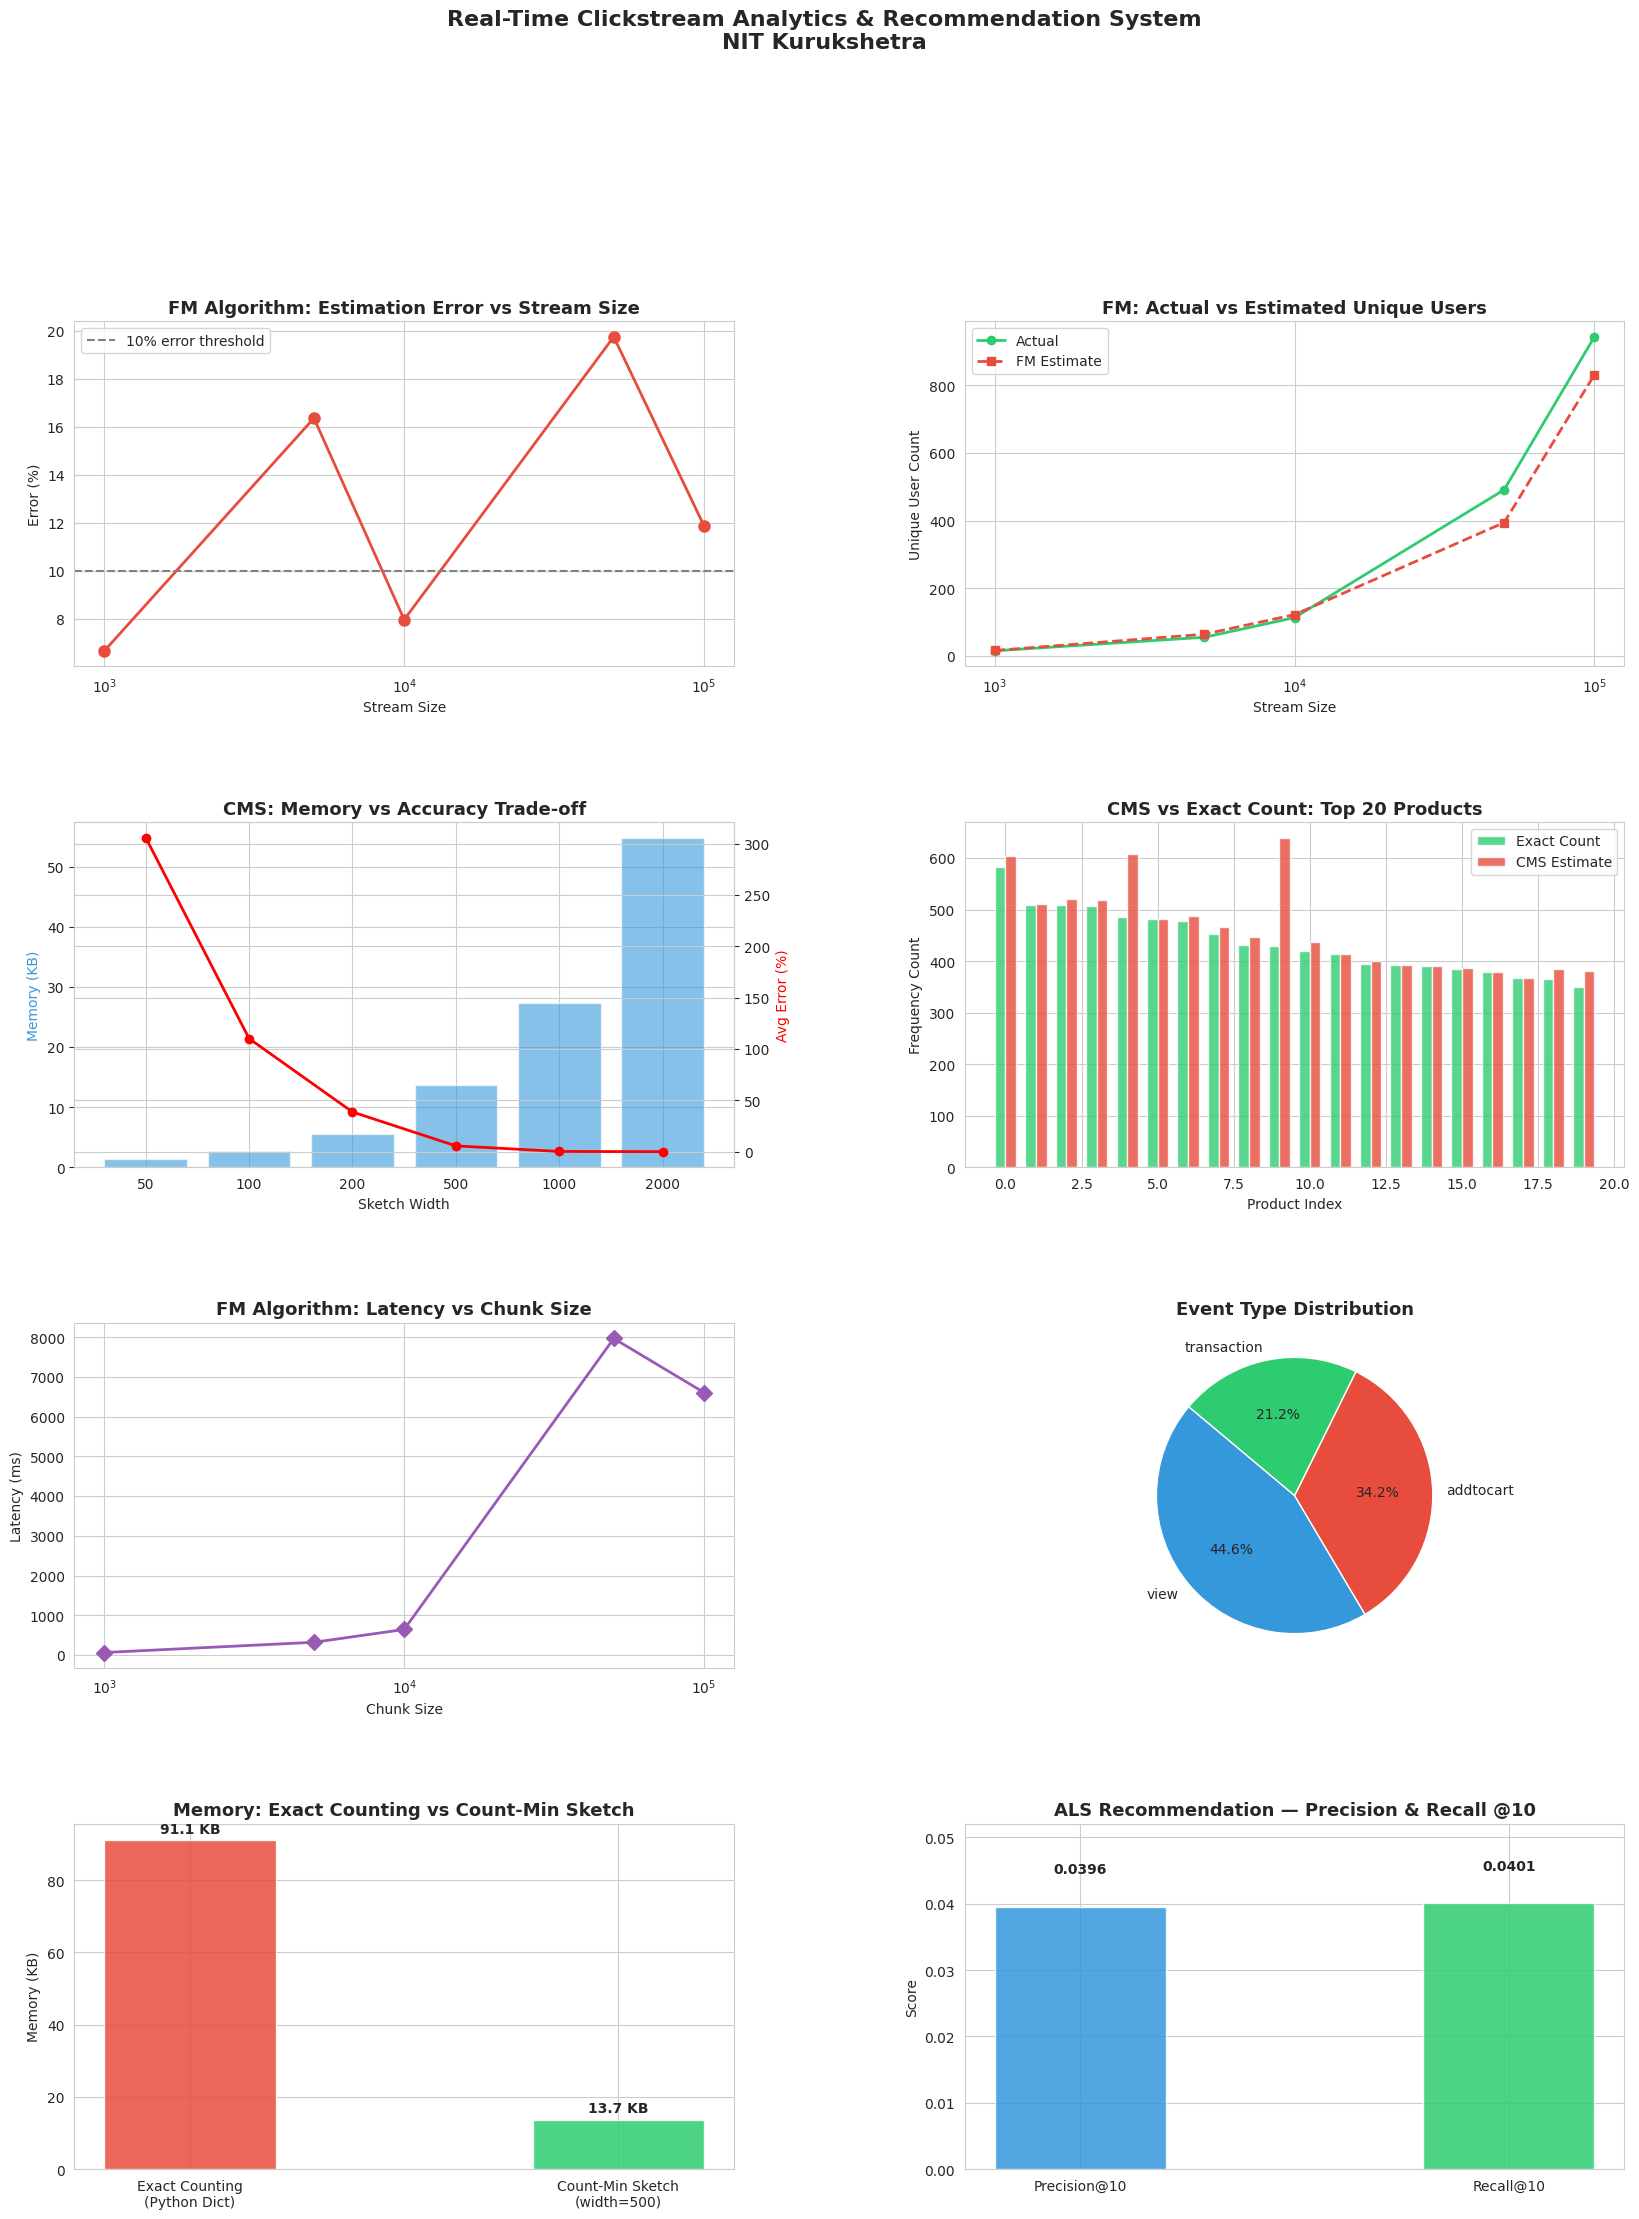

Visualization saved!


In [ ]:
# ============================================================
# CELL 22 — ALL VISUALIZATIONS
# ============================================================

sns.set_style("whitegrid")
fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: FM Error vs Stream Size ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(stream_sizes, fm_errors_list, 'o-', color='#E74C3C', linewidth=2, markersize=8)
ax1.axhline(y=10, color='gray', linestyle='--', label='10% error threshold')
ax1.set_title('FM Algorithm: Estimation Error vs Stream Size', fontsize=13, fontweight='bold')
ax1.set_xlabel('Stream Size')
ax1.set_ylabel('Error (%)')
ax1.set_xscale('log')
ax1.legend()

# --- Plot 2: FM Actual vs Estimated ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(stream_sizes, fm_actual_vals,    'o-',  color='#2ECC71', label='Actual',      linewidth=2)
ax2.plot(stream_sizes, fm_estimated_vals, 's--', color='#E74C3C', label='FM Estimate', linewidth=2)
ax2.set_title('FM: Actual vs Estimated Unique Users', fontsize=13, fontweight='bold')
ax2.set_xlabel('Stream Size')
ax2.set_ylabel('Unique User Count')
ax2.set_xscale('log')
ax2.legend()

# --- Plot 3: CMS Memory vs Accuracy Trade-off ---
ax3      = fig.add_subplot(gs[1, 0])
ax3_twin = ax3.twinx()
ax3.bar(range(len(cms_widths)), cms_mem_kb, color='#3498DB', alpha=0.6, label='Memory (KB)')
ax3_twin.plot(range(len(cms_widths)), cms_avg_err, 'ro-', linewidth=2, label='Error (%)')
ax3.set_xticks(range(len(cms_widths)))
ax3.set_xticklabels([str(w) for w in cms_widths])
ax3.set_xlabel('Sketch Width')
ax3.set_ylabel('Memory (KB)', color='#3498DB')
ax3_twin.set_ylabel('Avg Error (%)', color='red')
ax3.set_title('CMS: Memory vs Accuracy Trade-off', fontsize=13, fontweight='bold')

# --- Plot 4: CMS vs Exact Count (Top 20 Products) ---
ax4 = fig.add_subplot(gs[1, 1])
x   = np.arange(len(top_products))
w   = 0.35
ax4.bar(x - w/2, exact_values,  w, label='Exact Count', color='#2ECC71', alpha=0.8)
ax4.bar(x + w/2, cms_estimates, w, label='CMS Estimate', color='#E74C3C', alpha=0.8)
ax4.set_title('CMS vs Exact Count: Top 20 Products', fontsize=13, fontweight='bold')
ax4.set_xlabel('Product Index')
ax4.set_ylabel('Frequency Count')
ax4.legend()

# --- Plot 5: FM Latency per Chunk ---

ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(chunk_sizes, chunk_latency, 'D-', color='#9B59B6', linewidth=2, markersize=8)
ax5.set_title('FM Algorithm: Latency vs Chunk Size', fontsize=13, fontweight='bold')
ax5.set_xlabel('Chunk Size')
ax5.set_ylabel('Latency (ms)')
ax5.set_xscale('log')

# --- Plot 6: Event Type Distribution ---
ax6          = fig.add_subplot(gs[2, 1])
event_counts = stream_data['event'].value_counts()
ax6.pie(event_counts.values, labels=event_counts.index,
        autopct='%1.1f%%', colors=['#3498DB','#E74C3C','#2ECC71'], startangle=140)
ax6.set_title('Event Type Distribution', fontsize=13, fontweight='bold')

# --- Plot 7: Memory Comparison ---
ax7        = fig.add_subplot(gs[3, 0])
mem_labels = ['Exact Counting\n(Python Dict)', 'Count-Min Sketch\n(width=500)']
mem_values = [exact_peak_mem / 1024, cms.memory_bytes() / 1024]
bars       = ax7.bar(mem_labels, mem_values, color=['#E74C3C', '#2ECC71'], alpha=0.85, width=0.4)
for bar, val in zip(bars, mem_values):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:.1f} KB', ha='center', fontweight='bold')
ax7.set_title('Memory: Exact Counting vs Count-Min Sketch', fontsize=13, fontweight='bold')
ax7.set_ylabel('Memory (KB)')

# --- Plot 8: ALS Evaluation Metrics ---
ax8     = fig.add_subplot(gs[3, 1])
metrics = [f'Precision@{K}', f'Recall@{K}']
values  = [precision_at_k, recall_at_k]
bars    = ax8.bar(metrics, values, color=['#3498DB','#2ECC71'], alpha=0.85, width=0.4)
for bar, val in zip(bars, values):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontweight='bold')
ax8.set_title(f'ALS Recommendation — Precision & Recall @{K}', fontsize=13, fontweight='bold')
ax8.set_ylim(0, max(values) * 1.3 if max(values) > 0 else 1)
ax8.set_ylabel('Score')

plt.suptitle(
    'Real-Time Clickstream Analytics & Recommendation System\nNIT Kurukshetra',
    fontsize=16, fontweight='bold', y=1.01
)
plt.savefig('bigdata_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved!")


In [ ]:
# ============================================================
# CELL 23 — FINAL SUMMARY
# ============================================================

print("\n" + "="*60)
print("           FINAL PROJECT SUMMARY")
print("="*60)
print(f"  Dataset          : MovieLens 100K ({len(events):,} events)")
print(f"  Stream Simulated : {len(stream_data):,} events")
print()
print(f"  [FM Algorithm]")
print(f"    Hash Functions  : 64 (8 groups × 8)")
print(f"    Estimated Users : {fm_estimate:,}")
print(f"    Actual Users    : {actual_users:,}")
print(f"    Error           : {fm_error:.2f}%")
print()
print(f"  [Count-Min Sketch]")
print(f"    Width × Depth   : 500 × 7")
print(f"    Avg Error       : {np.mean(cms_errors):.2f}%")
print(f"    Memory (CMS)    : {cms.memory_bytes()/1024:.1f} KB")
print(f"    Memory Saving   : {exact_peak_mem/cms.memory_bytes():.1f}x over exact counting")
print()
print(f"  [ALS Recommendation Engine]")
print(f"    Latent Factors  : 20  |  Reg: 0.1  |  Iterations: 10")
print(f"    RMSE            : {rmse:.4f}")
print(f"    Precision@{K}    : {precision_at_k:.4f}  ({precision_at_k*100:.2f}%)")
print(f"    Recall@{K}       : {recall_at_k:.4f}  ({recall_at_k*100:.2f}%)")
print(f"    Train Time      : {als_train_time:.1f}s")
print("="*60)

print()
print("="*60)
print("       ALGORITHM COMPARISON TABLE")
print("="*60)
print(f"  {'Algorithm':<22} {'Type':<15} {'Error':<12} {'Memory'}")
print(f"  {'-'*55}")
print(f"  {'Flajolet-Martin':<22} {'Probabilistic':<15} {fm_error:.2f}%{'':>5} {'2 KB (bitmap)'}")
print(f"  {'Count-Min Sketch':<22} {'Probabilistic':<15} {np.mean(cms_errors):.2f}%{'':>5} {cms.memory_bytes()/1024:.1f} KB")
print(f"  {'Exact Counting':<22} {'Deterministic':<15} {'0.00%':<12} {exact_peak_mem/1024:.1f} KB")
print(f"  {'-'*55}")
print(f"  FM uses {exact_peak_mem/(64*32/8):.0f}x less memory than exact for {fm_error:.1f}% error")
print(f"  CMS uses {exact_peak_mem/cms.memory_bytes():.1f}x less memory than exact for {np.mean(cms_errors):.1f}% error")

print()
print("="*60)
print("           REFERENCES")
print("="*60)
print("  [1] Flajolet, P. & Martin, G. (1985)")
print("      Probabilistic Counting Algorithms for")
print("      Data Base Applications. Journal of CSS.")
print()
print("  [2] Cormode, G. & Muthukrishnan, S. (2005)")
print("      An Improved Data Stream Summary: The")
print("      Count-Min Sketch and its Applications.")
print()
print("  [3] Koren, Y., Bell, R. & Volinsky, C. (2009)")
print("      Matrix Factorization Techniques for")
print("      Recommender Systems. IEEE Computer.")
print()
print("  [4] Harper, F. & Konstan, J. (2015)")
print("      The MovieLens Datasets: History and Context.")
print("      ACM TIIS.")
print("="*60)


           FINAL PROJECT SUMMARY
  Dataset          : MovieLens 100K (100,000 events)
  Stream Simulated : 100,000 events

  [FM Algorithm]
    Hash Functions  : 64 (8 groups × 8)
    Estimated Users : 831
    Actual Users    : 943
    Error           : 11.88%

  [Count-Min Sketch]
    Width × Depth   : 500 × 7
    Avg Error       : 5.63%
    Memory (CMS)    : 13.7 KB
    Memory Saving   : 6.7x over exact counting

  [ALS Recommendation Engine]
    Latent Factors  : 20  |  Reg: 0.1  |  Iterations: 10
    RMSE            : 0.9195
    Precision@10    : 0.0396  (3.96%)
    Recall@10       : 0.0401  (4.01%)
    Train Time      : 13.4s

       ALGORITHM COMPARISON TABLE
  Algorithm              Type            Error        Memory
  -------------------------------------------------------
  Flajolet-Martin        Probabilistic   11.88%      2 KB (bitmap)
  Count-Min Sketch       Probabilistic   5.63%      13.7 KB
  Exact Counting         Deterministic   0.00%        91.1 KB
  ---------------

In [ ]:
import pandas as pd
from pyspark.sql.functions import col, avg, countDistinct, count

# ----------------------------
# KPI
# ----------------------------
total_users = spark_df.select(countDistinct("visitorid")).collect()[0][0]
total_events = spark_df.select(count("*")).collect()[0][0]
avg_rating = spark_df.select(avg("rating")).collect()[0][0]

avg_rating = round(avg_rating, 2)

kpi = pd.DataFrame({
    "metric": ["Total Users", "Total Events", "Avg Rating"],
    "value": [total_users, total_events, avg_rating]
})

kpi.to_csv("kpi.csv", index=False)

# ----------------------------
# EVENT COUNTS (PANDAS FIX)
# ----------------------------
event_counts.to_csv("event_counts.csv")

# ----------------------------
# TIME SERIES
# ----------------------------
clean_df = windowed_events.select(
    col("window.start").alias("start_time"),
    col("window.end").alias("end_time"),
    col("event"),
    col("event_count")
)

clean_df.toPandas().to_csv("time_series.csv", index=False)

# ----------------------------
# TRENDING
# ----------------------------
exact_trending.toPandas().to_csv("trending.csv", index=False)

print("✅ All CSV files created successfully!")

✅ All CSV files created successfully!


In [ ]:
!ls

bigdata_results.png  ml-100k		  sample_data		 trending.csv
event_counts.csv     ml-100k.zip	  streaming_results.png
kpi.csv		     recommendations.csv  time_series.csv


In [ ]:
!zip -r project_files.zip *.csv

  adding: event_counts.csv (stored 0%)
  adding: kpi.csv (deflated 10%)
  adding: recommendations.csv (deflated 59%)
  adding: time_series.csv (deflated 90%)
  adding: trending.csv (deflated 60%)


In [ ]:
from google.colab import files
files.download("project_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>